In [100]:
import pandas as pd
import numpy as np
import re
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import matplotlib.pyplot as plt
import seaborn as sns

# SemEval Analysis 
### (BIG DISCLAIMER: For SemEval, there are several rows that have 0 labels. I left them in as I felt they were important except for certain visualizations. Look over to make sure some analysis doesn’t require ONLY labeled rows.)

In [101]:
S_train = pd.read_csv("SemEvalDataset/processed/train.csv")
S_test = pd.read_csv("SemEvalDataset/processed/test.csv")

# Combine train and test into one dataframe
S_all = pd.concat(
    [S_train, S_test],
    ignore_index=True
)

In [102]:
custom_stopwords = set(ENGLISH_STOP_WORDS).union({
    "im", "ive", "dont", "didnt", "doesnt", "cant", "couldnt",
    "wouldnt", "isnt", "arent", "wasnt", "werent",
    "feel", "feeling", "felt", "like", "just", "really",
    "know", "time", "people", "day", "going", "want"
})

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    words = text.split()

    words = [
        word for word in words
        if word not in custom_stopwords and len(word) > 2
    ]

    return words

In [103]:
S_emotion_cols = [
    "anger", "anticipation", "disgust", "fear", "joy",
    "love", "optimism", "pessimism", "sadness",
    "surprise", "trust"
]

## SemEval Dataset Statistics

Here are some basic statistics about the dataset, such as total samples, number of emotion columns, and amount of multi-label samples.

In [104]:
S_all.columns = S_train.columns.str.strip()

S_all[S_emotion_cols] = (
    S_all[S_emotion_cols]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
    .astype(int)
)

In [169]:
print("Total samples in SemEval:", len(S_all))
print("Number of emotion columns:", len(S_emotion_cols))

S_labels_per_comment = S_all[S_emotion_cols].sum(axis=1)

print("Average labels per comment in SemEval:", S_labels_per_comment.mean())

S_multi_label = (S_labels_per_comment > 1).sum()
print("Multi-label samples in data:", S_multi_label)
print("Percentage of multi-label samples:", 100 * S_multi_label / len(S_all))

Total samples in SemEval: 10097
Number of emotion columns: 11
Average labels per comment in SemEval: 1.589382985045063
Multi-label samples in data: 5652
Percentage of multi-label samples: 55.9770228780826


In [106]:
S_all["num_labels"] = S_all[S_emotion_cols].sum(axis=1)
S_labeled = S_all[S_all["num_labels"] > 0].copy()

In [107]:
S_labeled["word_count"] = S_labeled["Tweet"].apply(
    lambda text: len(str(text).split())
)

S_labeled["clean_word_count"] = S_labeled["Tweet"].apply(
    lambda text: len(clean_text(text))
)

S_labeled["char_count"] = S_labeled["Tweet"].apply(
    lambda text: len(str(text))
)

## RQ 1. How emotionally complex are comments in the dataset? (Number of labels per comment)

This is a multilabel dataset, meaning a comment can have more than one emotion label. We want to see how many comments have 1, 2, 3 amount of labels given to them.

num_labels
1     982
2    2773
3    2114
4     658
5      96
6      11
Name: count, dtype: int64


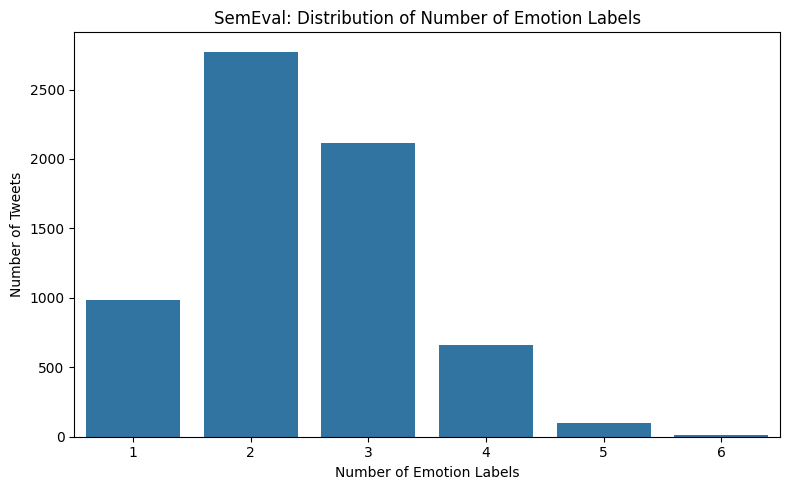

In [164]:
label_distribution = (
    S_all["num_labels"]
    .value_counts()
    .sort_index()
)

print(label_distribution)

plt.figure(figsize=(8,5))

sns.barplot(
    x=label_distribution.index,
    y=label_distribution.values
)

plt.title("SemEval: Distribution of Number of Emotion Labels")
plt.xlabel("Number of Emotion Labels")
plt.ylabel("Number of Tweets")

plt.tight_layout()
plt.show()

While this just shows us the bars, we can see what kinds of emotion combinations show up for each bar.

## These results are meant for RQ 2. Which emotions most frequently occur together in human language? (Most common emotion combinations & Co-occurance matrix)

In [ ]:
from collections import Counter
import pandas as pd

# Make sure emotion columns are numeric
S_all[S_emotion_cols] = (
    S_all[S_emotion_cols]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
    .astype(int)
)

# Create label_names column for SemEval
S_all["label_names"] = S_all[S_emotion_cols].apply(
    lambda row: [emotion for emotion in S_emotion_cols if row[emotion] == 1],
    axis=1
)

def create_combo_df(df):
    combos = df["label_names"].apply(
        lambda x: tuple(sorted(x)) if len(x) > 0 else ("no_label",)
    )

    combo_counts = Counter(combos)

    combo_df = pd.DataFrame(
        combo_counts.items(),
        columns=["Emotion Combination", "Count"]
    )

    combo_df["Percent"] = (
        combo_df["Count"] / len(df) * 100
    ).round(2)

    combo_df = combo_df.sort_values(
        "Count",
        ascending=False
    ).reset_index(drop=True)

    return combo_df


S_0label_combos = create_combo_df(S_all[S_all["num_labels"] == 0])
S_1label_combos = create_combo_df(S_all[S_all["num_labels"] == 1])
S_2label_combos = create_combo_df(S_all[S_all["num_labels"] == 2])
S_3label_combos = create_combo_df(S_all[S_all["num_labels"] == 3])
S_4label_combos = create_combo_df(S_all[S_all["num_labels"] == 4])
S_5label_combos = create_combo_df(S_all[S_all["num_labels"] == 5])
S_6label_combos = create_combo_df(S_all[S_all["num_labels"] == 6])

In [165]:
S_0label_combos

,Emotion Combination,Count,Percent
0,"(no_label,)",3463,100.0


In [137]:
S_1label_combos

,Emotion Combination,Count,Percent
0,"(joy,)",275,28.00
1,"(fear,)",175,17.82
2,"(sadness,)",172,17.52
3,"(anger,)",108,11.00
4,"(optimism,)",95,9.67
5,"(anticipation,)",66,6.72
6,"(disgust,)",55,5.60
7,"(surprise,)",17,1.73
8,"(pessimism,)",15,1.53
9,"(love,)",4,0.41


In [155]:
S_2label_combos

,Emotion Combination,Count,Percent
0,"(anger, disgust)",865,31.19
1,"(joy, optimism)",538,19.40
2,"(pessimism, sadness)",174,6.27
3,"(joy, love)",155,5.59
4,"(fear, sadness)",113,4.08
5,"(disgust, sadness)",93,3.35
6,"(anticipation, joy)",74,2.67
7,"(anger, sadness)",73,2.63
8,"(fear, pessimism)",55,1.98
9,"(joy, sadness)",51,1.84


In [157]:
S_3label_combos

,Emotion Combination,Count,Percent
0,"(anger, disgust, sadness)",446,21.10
1,"(joy, love, optimism)",308,14.57
2,"(anger, disgust, fear)",157,7.43
3,"(anticipation, joy, optimism)",146,6.91
4,"(joy, optimism, trust)",81,3.83
...,...,...,...
98,"(anticipation, love, sadness)",1,0.05
99,"(disgust, sadness, trust)",1,0.05
100,"(love, pessimism, sadness)",1,0.05
101,"(anger, joy, trust)",1,0.05


In [159]:
S_4label_combos

,Emotion Combination,Count,Percent
0,"(anger, disgust, pessimism, sadness)",87,13.22
1,"(anger, disgust, fear, sadness)",85,12.92
2,"(joy, love, optimism, trust)",40,6.08
3,"(anticipation, joy, optimism, trust)",35,5.32
4,"(anticipation, joy, love, optimism)",32,4.86
...,...,...,...
106,"(anticipation, optimism, sadness, trust)",1,0.15
107,"(anticipation, joy, pessimism, surprise)",1,0.15
108,"(fear, optimism, sadness, trust)",1,0.15
109,"(disgust, love, pessimism, sadness)",1,0.15


In [161]:
S_5label_combos

,Emotion Combination,Count,Percent
0,"(anger, disgust, fear, pessimism, sadness)",19,19.79
1,"(anticipation, joy, love, optimism, trust)",10,10.42
2,"(anger, disgust, fear, sadness, surprise)",4,4.17
3,"(anger, anticipation, disgust, fear, sadness)",4,4.17
4,"(anger, anticipation, disgust, fear, pessimism)",3,3.12
5,"(anticipation, joy, optimism, surprise, trust)",3,3.12
6,"(anger, disgust, optimism, pessimism, sadness)",2,2.08
7,"(anger, disgust, joy, optimism, sadness)",2,2.08
8,"(anger, disgust, fear, optimism, sadness)",2,2.08
9,"(fear, joy, love, optimism, trust)",2,2.08


In [142]:
S_6label_combos

,Emotion Combination,Count,Percent
0,"(anticipation, joy, love, optimism, surprise, trust)",3,27.27
1,"(anger, disgust, fear, joy, love, sadness)",1,9.09
2,"(anger, anticipation, disgust, fear, joy, optimism)",1,9.09
3,"(disgust, joy, optimism, pessimism, sadness, trust)",1,9.09
4,"(disgust, joy, optimism, pessimism, surprise, trust)",1,9.09
5,"(anticipation, disgust, fear, joy, pessimism, sadness)",1,9.09
6,"(fear, joy, love, optimism, sadness, surprise)",1,9.09
7,"(anger, anticipation, disgust, fear, sadness, surprise)",1,9.09
8,"(anger, anticipation, disgust, fear, pessimism, sadness)",1,9.09


## RQ 3. Which emotions are most and least represented in the dataset? (Emotion Frequency Distribution)


In this section we want to see the frequency of each emotion label.

In [166]:
S_emotion_counts = S_all[S_emotion_cols].sum().sort_values(ascending=False)

S_total_tweets = len(S_all)
S_total_label_assignments = S_all[S_emotion_cols].sum().sum()

S_emotion_freq_table = pd.DataFrame({
    "Emotion": S_emotion_counts.index,
    "Count": S_emotion_counts.values,
    "% of Tweets": (S_emotion_counts.values / S_total_tweets * 100).round(2),
    "% of Label Assignments": (S_emotion_counts.values / S_total_label_assignments * 100).round(2)
})

S_emotion_freq_table

,Emotion,Count,% of Tweets,% of Label Assignments
0,disgust,2602,25.77,16.21
1,anger,2544,25.20,15.85
2,joy,2477,24.53,15.43
3,sadness,2008,19.89,12.51
4,optimism,1984,19.65,12.36
5,fear,1242,12.30,7.74
6,anticipation,978,9.69,6.09
7,pessimism,795,7.87,4.95
8,love,700,6.93,4.36
9,surprise,361,3.58,2.25


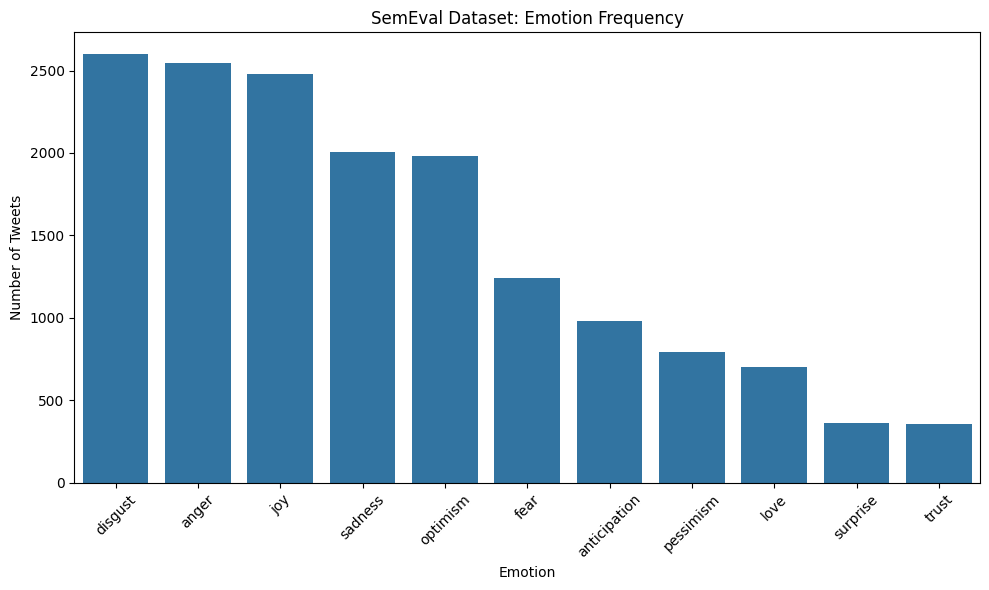

In [111]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=S_emotion_freq_table,
    x="Emotion",
    y="Count"
)

plt.title("SemEval Dataset: Emotion Frequency")
plt.xlabel("Emotion")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## RQ 4. Do emotions appear differently in comments referencing males versus females? (Pronoun-Based Gender Comparison)

This section aims to compare the emotion labels assigned to the male and female gender. The genders are inferred by checking whether the text contains only male or only female pronouns. 

In [112]:
S_male_mask = S_all["Tweet"].str.contains(
    r"\b(he|him|his)\b",
    case=False,
    regex=True,
    na=False
)

S_female_mask = S_all["Tweet"].str.contains(
    r"\b(she|her|hers)\b",
    case=False,
    regex=True,
    na=False
)

S_male_comments = S_all[S_male_mask & ~S_female_mask]
S_female_comments = S_all[S_female_mask & ~S_male_mask]

print("Male comments:", len(S_male_comments))
print("Female comments:", len(S_female_comments))

Male comments: 695
Female comments: 381


/var/folders/13/553h520n4_56sbjhxtryvs340000gn/T/ipykernel_50710/1513903335.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  S_male_mask = S_all["Tweet"].str.contains(
/var/folders/13/553h520n4_56sbjhxtryvs340000gn/T/ipykernel_50710/1513903335.py:8: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  S_female_mask = S_all["Tweet"].str.contains(


In [113]:
S_male_pct = (
    S_male_comments[S_emotion_cols].sum()
    / len(S_male_comments)
    * 100
)

S_female_pct = (
    S_female_comments[S_emotion_cols].sum()
    / len(S_female_comments)
    * 100
)

S_comparison = pd.DataFrame({
    "Male %": S_male_pct,
    "Female %": S_female_pct
})

S_comparison["Difference"] = (
    S_comparison["Female %"] - S_comparison["Male %"]
)

S_comparison = S_comparison.sort_values(
    "Difference",
    ascending=False
)

S_comparison

,Male %,Female %,Difference
love,6.906475,12.335958,5.429483
sadness,16.258993,18.110236,1.851243
anticipation,8.776978,10.236220,1.459242
surprise,3.453237,4.461942,1.008705
pessimism,6.906475,7.874016,0.967541
trust,3.597122,4.199475,0.602353
joy,24.604317,24.934383,0.330067
optimism,16.978417,16.535433,-0.442984
fear,11.366906,9.711286,-1.655620
disgust,31.798561,26.509186,-5.289375


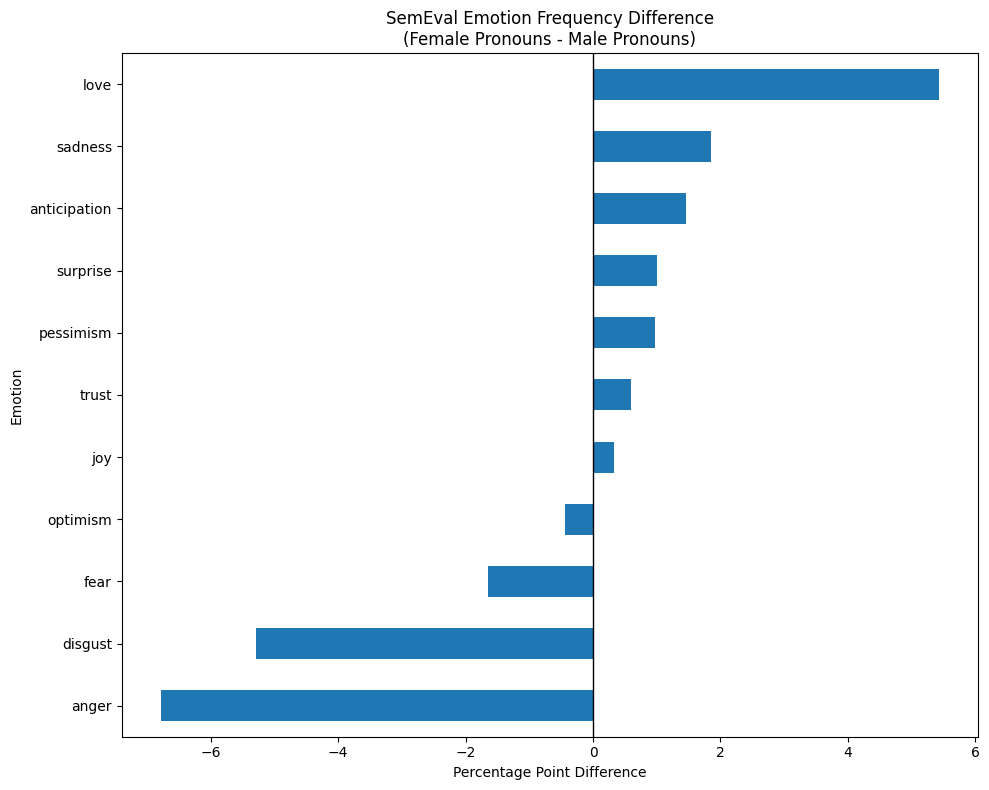

In [114]:
S_comparison["Difference"].sort_values().plot(
    kind="barh",
    figsize=(10, 8)
)

plt.title("SemEval Emotion Frequency Difference\n(Female Pronouns - Male Pronouns)")
plt.xlabel("Percentage Point Difference")
plt.ylabel("Emotion")

plt.axvline(0, color="black", linewidth=1)
plt.tight_layout()
plt.show()

## RQ 5. Which words are most strongly associated with each emotion category? (Most common words per emotion)

In [115]:
summary_rows = []

for emotion in S_emotion_cols:

    emotion_texts = S_all.loc[
        S_all[emotion] == 1,
        "Tweet"
    ]

    all_words = []

    for text in emotion_texts:
        all_words.extend(clean_text(text))

    top_words = [
        word
        for word, count in Counter(all_words).most_common(10)
    ]

    summary_rows.append({
        "Emotion": emotion,
        "Most Common Words": top_words
    })

pd.set_option("display.max_colwidth", None)

S_emotion_word_table = pd.DataFrame(summary_rows)

S_emotion_word_table

,Emotion,Most Common Words
0,anger,"[don, amp, angry, anger, fucking, awful, terrible, got, rage, fuming]"
1,anticipation,"[amp, don, start, think, watch, new, blues, good, make, need]"
2,disgust,"[don, amp, awful, terrible, angry, fucking, got, think, make, horrible]"
3,fear,"[fear, anxiety, nervous, nightmare, don, terrorism, amp, horror, panic, terror]"
4,joy,"[happy, love, amp, good, smile, don, watch, amazing, hilarious, lol]"
5,love,"[love, happy, smile, amp, good, amazing, birthday, laughter, watch, life]"
6,optimism,"[happy, good, don, love, amp, life, smile, make, optimism, today]"
7,pessimism,"[don, sad, depression, life, sadness, lost, amp, think, depressing, today]"
8,sadness,"[sad, don, amp, depression, sadness, lost, today, got, depressing, life]"
9,surprise,"[shocking, amp, watch, did, amazing, hilarious, don, lol, live, didn]"


## RQ 2. Which emotions most frequently occur together in human language? (Most common emotion combinations & Co-occurance matrix)

In this section we want to see what kinds of emotions occur together in the multilabel comments, and infer whether there are any special relationships. A bit of this was already explored in the label distribution section.

These first 3 chunks of code are meant for a co-occurance matrix, looking at pairs of 2 emotion labels, rather than 3, 4, 5, and 6.

In [146]:
S_cooccurrence = (
    S_all[S_emotion_cols]
    .T
    .dot(S_all[S_emotion_cols])
)

for emotion in S_emotion_cols:
    S_cooccurrence.loc[emotion, emotion] = 0

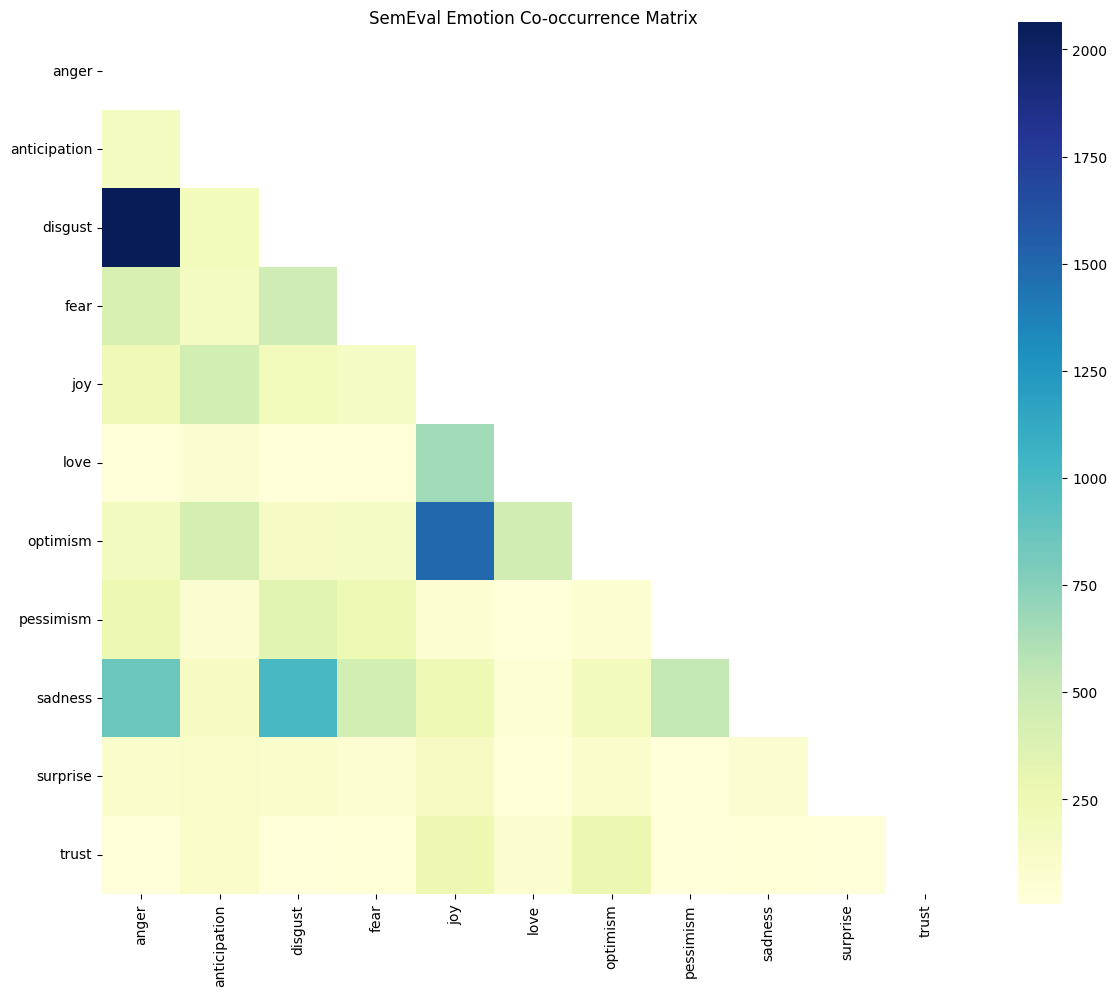

In [147]:
# Hide duplicate half of matrix
mask = np.triu(
    np.ones_like(S_cooccurrence, dtype=bool)
)

plt.figure(figsize=(12,10))

sns.heatmap(
    S_cooccurrence,
    mask=mask,
    cmap="YlGnBu",
    square=True
)

plt.title("SemEval Emotion Co-occurrence Matrix")

plt.tight_layout()
plt.show()

In [148]:
pairs = []

for i, emotion1 in enumerate(S_emotion_cols):
    for emotion2 in S_emotion_cols[i+1:]:

        count = (
            (S_all[emotion1] == 1)
            &
            (S_all[emotion2] == 1)
        ).sum()

        pairs.append([
            emotion1,
            emotion2,
            count
        ])

S_top_pairs = pd.DataFrame(
    pairs,
    columns=[
        "Emotion1",
        "Emotion2",
        "Count"
    ]
)

S_top_pairs = S_top_pairs.sort_values(
    "Count",
    ascending=False
)

S_top_pairs.head(20)

,Emotion1,Emotion2,Count
1,anger,disgust,2064
35,joy,optimism,1495
24,disgust,sadness,1005
7,anger,sadness,865
34,joy,love,655
49,pessimism,sadness,537
19,disgust,fear,477
40,love,optimism,453
12,anticipation,joy,448
31,fear,sadness,445


In [149]:

cooccurrence_table = []

for emotion in S_emotion_cols:

    emotion_rows = S_all[S_all[emotion] == 1]

    pairs = []

    for other_emotion in S_emotion_cols:

        if other_emotion == emotion:
            continue

        count = emotion_rows[other_emotion].sum()

        if count > 0:
            pairs.append(
                (other_emotion, int(count))
            )

    pairs = sorted(
        pairs,
        key=lambda x: x[1],
        reverse=True
    )

    cooccurrence_table.append(
        {
            "Emotion": emotion,
            "Co-Occurring Emotions": pairs
        }
    )

cooccurrence_df = pd.DataFrame(cooccurrence_table)

pd.set_option("display.max_colwidth", None)

cooccurrence_df

,Emotion,Co-Occurring Emotions
0,anger,"[(disgust, 2064), (sadness, 865), (fear, 402), (pessimism, 257), (joy, 218), (optimism, 177), (anticipation, 167), (surprise, 93), (trust, 22), (love, 17)]"
1,anticipation,"[(joy, 448), (optimism, 425), (disgust, 195), (anger, 167), (fear, 160), (sadness, 152), (trust, 117), (surprise, 115), (love, 73), (pessimism, 64)]"
2,disgust,"[(anger, 2064), (sadness, 1005), (fear, 477), (pessimism, 340), (joy, 212), (anticipation, 195), (optimism, 141), (surprise, 98), (trust, 16), (love, 15)]"
3,fear,"[(disgust, 477), (sadness, 445), (anger, 402), (pessimism, 233), (anticipation, 160), (joy, 151), (optimism, 150), (surprise, 58), (trust, 28), (love, 20)]"
4,joy,"[(optimism, 1495), (love, 655), (anticipation, 448), (trust, 249), (sadness, 233), (anger, 218), (disgust, 212), (surprise, 159), (fear, 151), (pessimism, 56)]"
5,love,"[(joy, 655), (optimism, 453), (trust, 82), (anticipation, 73), (sadness, 48), (surprise, 28), (fear, 20), (anger, 17), (disgust, 15), (pessimism, 10)]"
6,optimism,"[(joy, 1495), (love, 453), (anticipation, 425), (trust, 278), (sadness, 185), (anger, 177), (fear, 150), (disgust, 141), (surprise, 93), (pessimism, 59)]"
7,pessimism,"[(sadness, 537), (disgust, 340), (anger, 257), (fear, 233), (anticipation, 64), (optimism, 59), (joy, 56), (surprise, 23), (love, 10), (trust, 7)]"
8,sadness,"[(disgust, 1005), (anger, 865), (pessimism, 537), (fear, 445), (joy, 233), (optimism, 185), (anticipation, 152), (surprise, 72), (love, 48), (trust, 25)]"
9,surprise,"[(joy, 159), (anticipation, 115), (disgust, 98), (anger, 93), (optimism, 93), (sadness, 72), (fear, 58), (love, 28), (pessimism, 23), (trust, 21)]"


In [168]:
cooccurrence_df["Num Co-Occurring Emotions"] = (
    cooccurrence_df["Co-Occurring Emotions"]
    .apply(len)
)

cooccurrence_df["Total Co-Occurrences"] = (
    cooccurrence_df["Co-Occurring Emotions"]
    .apply(lambda pairs: sum(count for _, count in pairs))
)

top5 = (
    cooccurrence_df
    .sort_values(
        by=[
            "Num Co-Occurring Emotions",
            "Total Co-Occurrences"
        ],
        ascending=[False, False]
    )
    .head(5)
)

top5

,Emotion,Co-Occurring Emotions,Num Co-Occurring Emotions,Total Co-Occurrences
2,disgust,"[(anger, 2064), (sadness, 1005), (fear, 477), (pessimism, 340), (joy, 212), (anticipation, 195), (optimism, 141), (surprise, 98), (trust, 16), (love, 15)]",10,4563
0,anger,"[(disgust, 2064), (sadness, 865), (fear, 402), (pessimism, 257), (joy, 218), (optimism, 177), (anticipation, 167), (surprise, 93), (trust, 22), (love, 17)]",10,4282
4,joy,"[(optimism, 1495), (love, 655), (anticipation, 448), (trust, 249), (sadness, 233), (anger, 218), (disgust, 212), (surprise, 159), (fear, 151), (pessimism, 56)]",10,3876
8,sadness,"[(disgust, 1005), (anger, 865), (pessimism, 537), (fear, 445), (joy, 233), (optimism, 185), (anticipation, 152), (surprise, 72), (love, 48), (trust, 25)]",10,3567
6,optimism,"[(joy, 1495), (love, 453), (anticipation, 425), (trust, 278), (sadness, 185), (anger, 177), (fear, 150), (disgust, 141), (surprise, 93), (pessimism, 59)]",10,3456


## RQ 6. Which emotions are expressed using the most diverse vocabulary? (Lexical Richness and Vocabulary Size)

In this section we will be conducting text analysis on the comments. This includes looking at all the unique words in the data (referred to as vocabulary size), the total number of words, and lexical richness, which is the number of unique words divided by the total words. 

In [119]:
S_train_labeled = S_all[S_all["num_labels"] > 0].copy()

In [120]:
all_words = []

for text in S_labeled["Tweet"]:
    all_words.extend(clean_text(text))

vocab_size = len(set(all_words))
total_words = len(all_words)
lexical_richness = vocab_size / total_words

SemEval_diversity_summary = pd.DataFrame({
    "Metric": [
        "Total Words",
        "Vocabulary Size",
        "Lexical Richness"
    ],
    "Value": [
        total_words,
        vocab_size,
        lexical_richness
    ]
})

SemEval_diversity_summary

,Metric,Value
0,Total Words,53278.000000
1,Vocabulary Size,14534.000000
2,Lexical Richness,0.272796


In [121]:
diversity_rows = []

for emotion in S_emotion_cols:

    emotion_texts = S_labeled.loc[
        S_labeled[emotion] == 1,
        "Tweet"
    ]

    words = []

    for text in emotion_texts:
        words.extend(clean_text(text))

    total_words = len(words)
    unique_words = len(set(words))

    lexical_richness = (
        unique_words / total_words
        if total_words > 0 else 0
    )

    diversity_rows.append({
        "Emotion": emotion,
        "Sample Count": len(emotion_texts),
        "Total Words": total_words,
        "Unique Words": unique_words,
        "Lexical Richness": lexical_richness
    })

S_diversity_table = pd.DataFrame(diversity_rows)

S_diversity_table = S_diversity_table.sort_values(
    "Lexical Richness",
    ascending=False
)

S_diversity_table

,Emotion,Sample Count,Total Words,Unique Words,Lexical Richness
9,surprise,361,2847,1870,0.656832
10,trust,357,2961,1832,0.618710
1,anticipation,978,7955,4178,0.525204
7,pessimism,795,6082,3119,0.512825
5,love,700,5621,2789,0.496175
3,fear,1242,9997,4464,0.446534
8,sadness,2008,15672,6200,0.395610
6,optimism,1984,16193,6330,0.390910
4,joy,2477,19944,7468,0.374448
2,disgust,2602,21648,7914,0.365576


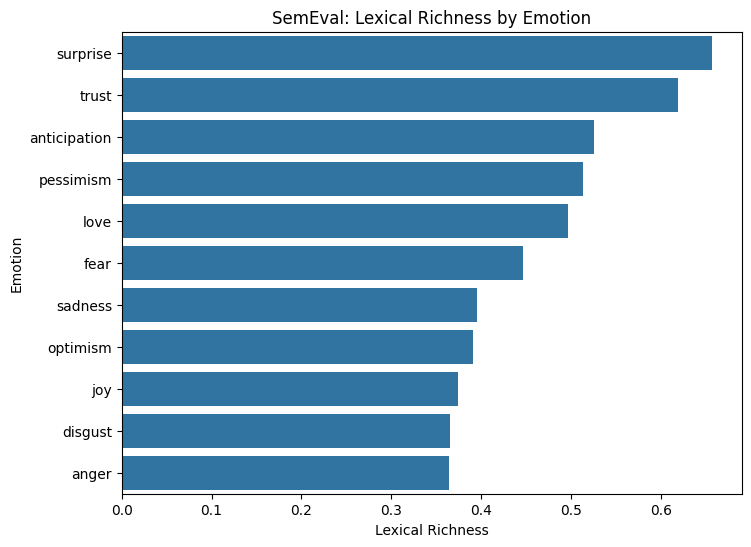

In [122]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=S_diversity_table,
    y="Emotion",
    x="Lexical Richness"
)

plt.title("SemEval: Lexical Richness by Emotion")
plt.xlabel("Lexical Richness")
plt.ylabel("Emotion")
plt.show()

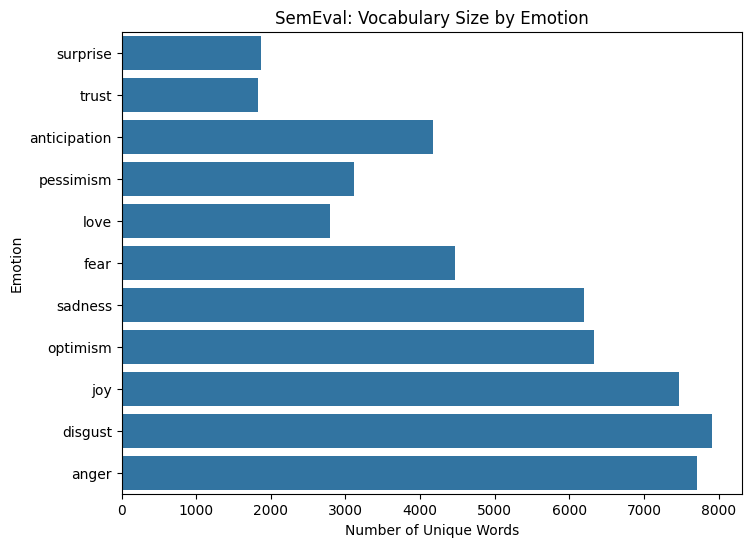

In [123]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=S_diversity_table,
    y="Emotion",
    x="Unique Words"
)

plt.title("SemEval: Vocabulary Size by Emotion")
plt.xlabel("Number of Unique Words")
plt.ylabel("Emotion")
plt.show()

In [124]:
S_diversity_table["Unique Words Per Sample"] = (
    S_diversity_table["Unique Words"]
    /
    S_diversity_table["Sample Count"]
)

S_diversity_table = S_diversity_table.sort_values(
    "Unique Words Per Sample",
    ascending=False
)

print(
    S_diversity_table[
        [
            "Emotion",
            "Sample Count",
            "Unique Words",
            "Unique Words Per Sample",
            "Lexical Richness"
        ]
    ]
)

         Emotion  Sample Count  Unique Words  Unique Words Per Sample  \
9       surprise           361          1870                 5.180055   
10         trust           357          1832                 5.131653   
1   anticipation           978          4178                 4.271984   
5           love           700          2789                 3.984286   
7      pessimism           795          3119                 3.923270   
3           fear          1242          4464                 3.594203   
6       optimism          1984          6330                 3.190524   
8        sadness          2008          6200                 3.087649   
2        disgust          2602          7914                 3.041507   
0          anger          2544          7715                 3.032626   
4            joy          2477          7468                 3.014937   

    Lexical Richness  
9           0.656832  
10          0.618710  
1           0.525204  
5           0.496175  
7       

## RQ 7. Emotion vs Comment Length (and Distribution of Comment Length)

This is mainly to see the distribution of comment length. How many comments are long/medium/short?

In [125]:
print("Average raw words per tweet:",
      S_labeled["word_count"].mean())

print("Median raw words per tweet:",
      S_labeled["word_count"].median())

print("Average cleaned words per tweet:",
      S_labeled["clean_word_count"].mean())

print("Median cleaned words per tweet:",
      S_labeled["clean_word_count"].median())

print("Average characters per tweet:",
      S_labeled["char_count"].mean())

Average raw words per tweet: 16.16355140186916
Median raw words per tweet: 17.0
Average cleaned words per tweet: 8.031052155562255
Median cleaned words per tweet: 8.0
Average characters per tweet: 95.70440156768164


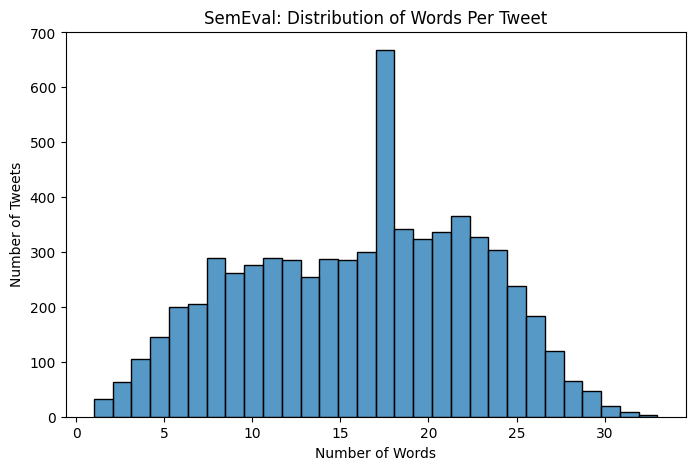

In [126]:
plt.figure(figsize=(8,5))

sns.histplot(
    S_labeled["word_count"],
    bins=30
)

plt.title("SemEval: Distribution of Words Per Tweet")
plt.xlabel("Number of Words")
plt.ylabel("Number of Tweets")
plt.show()

I conducted that same analysis across each emotion label. What emotions tend to have comments that are longer in length? I decided to observe this trend across both cleaned and non-cleaned comments.

In [127]:
length_rows = []

for emotion in S_emotion_cols:

    emotion_tweets = S_labeled[
        S_labeled[emotion] == 1
    ]

    length_rows.append({
        "Emotion": emotion,
        "Avg Raw Words": emotion_tweets["word_count"].mean(),
        "Median Raw Words": emotion_tweets["word_count"].median(),
        "Avg Cleaned Words": emotion_tweets["clean_word_count"].mean(),
        "Median Cleaned Words": emotion_tweets["clean_word_count"].median(),
        "Avg Characters": emotion_tweets["char_count"].mean(),
        "Sample Count": len(emotion_tweets)
    })

S_length_table = pd.DataFrame(length_rows)

S_length_table = S_length_table.sort_values(
    "Avg Raw Words",
    ascending=False
)

S_length_table

,Emotion,Avg Raw Words,Median Raw Words,Avg Cleaned Words,Median Cleaned Words,Avg Characters,Sample Count
0,anger,16.721305,18.0,8.323506,8.5,98.972877,2544
2,disgust,16.683705,18.0,8.319754,8.0,99.034973,2602
10,trust,16.568627,17.0,8.294118,8.0,98.885154,357
1,anticipation,16.384458,17.0,8.133947,8.0,97.389571,978
6,optimism,16.295867,17.0,8.161794,8.0,97.473790,1984
8,sadness,16.284861,17.0,7.804781,8.0,94.543825,2008
7,pessimism,16.237736,17.0,7.650314,8.0,93.987421,795
3,fear,16.128824,17.0,8.049114,8.0,96.475040,1242
4,joy,15.791280,16.0,8.051675,8.0,94.326605,2477
9,surprise,15.678670,16.0,7.886427,8.0,93.670360,361


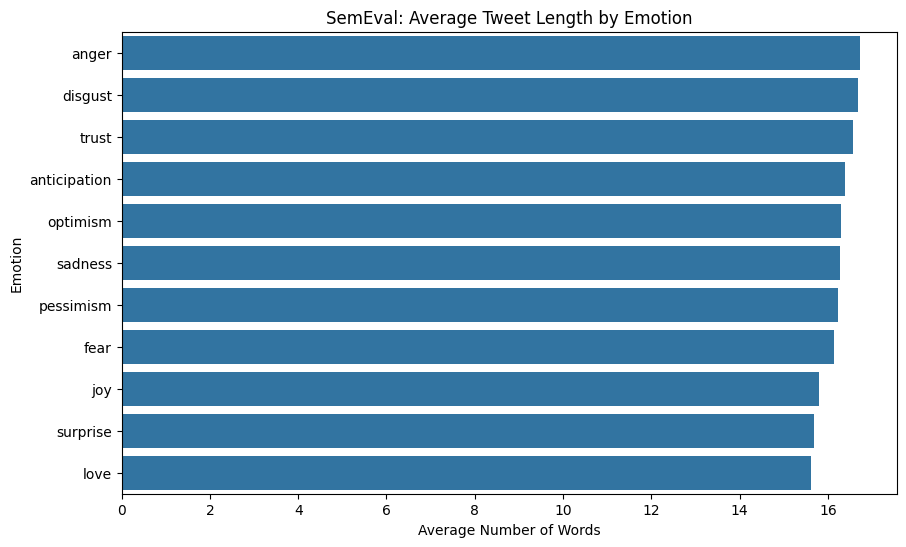

In [128]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=S_length_table,
    y="Emotion",
    x="Avg Raw Words"
)

plt.title("SemEval: Average Tweet Length by Emotion")
plt.xlabel("Average Number of Words")
plt.ylabel("Emotion")
plt.show()

In [129]:
length_records = []

for emotion in S_emotion_cols:

    emotion_tweets = S_labeled[
        S_labeled[emotion] == 1
    ]

    for count in emotion_tweets["word_count"]:
        length_records.append({
            "Emotion": emotion,
            "Word Count": count
        })

S_length_long = pd.DataFrame(length_records)

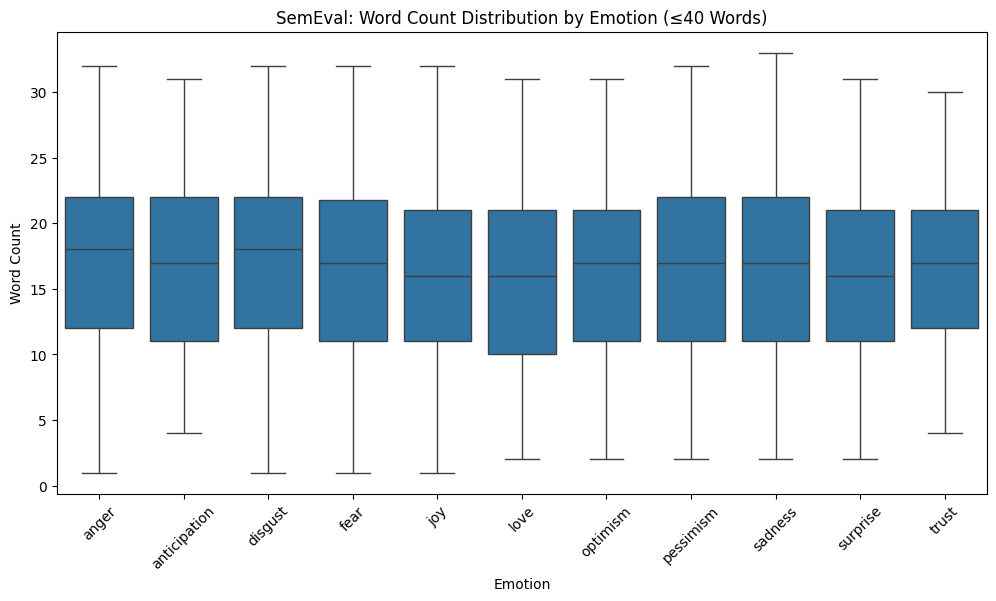

In [130]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=S_length_long[
        S_length_long["Word Count"] <= 40
    ],
    x="Emotion",
    y="Word Count"
)

plt.title("SemEval: Word Count Distribution by Emotion (≤40 Words)")
plt.xlabel("Emotion")
plt.ylabel("Word Count")
plt.xticks(rotation=45)
plt.show()

## Correlation between number of labels and word count

I grouped the data by both number of labels attatched and word count, and plotted a graph to see if there was a correlation.

<Axes: xlabel='num_labels', ylabel='word_count'>

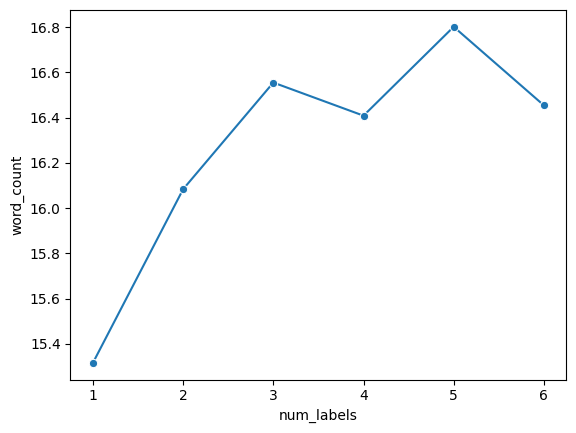

In [153]:
label_length = (
    S_labeled
    .groupby("num_labels")["word_count"]
    .mean()
    .reset_index()
)

sns.lineplot(
    data=label_length,
    x="num_labels",
    y="word_count",
    marker="o"
)

In [162]:
label_length

,num_labels,word_count
0,1,15.315682
1,2,16.083664
2,3,16.555345
3,4,16.408815
4,5,16.802083
5,6,16.454545
